# IOF Zone Research — Detection Prototype

## Research Question & Hypotheses

### Research Question

Does the first retest of an objectively defined Institutional Order Flow
(IOF) Supply/Demand zone produce a directional price reaction in ES futures
that is greater than would be expected from comparable non-IOF market
observations?

### Background

What is Institutional Order Flow (IOF)? IOF is a popular strategy among some discretionary traders. Essentially, IOF claims that when a large impulsive movement in price is followed by a period of consolidation, then a 2nd large impulsive movement in price, the area of consolidation is has now become a "zone". A supply zone if the 2nd impulse was bearish, or a demand zone if the 2nd impulse was bullish. The idea is that these zones can give a prediction to how price will react when entering these zones. That is what I am will be trying to find out.

### Null Hypothesis (H₀)

The first retest of an IOF zone does not produce a directional price
reaction greater than that observed at randomly selected entry points.

### Alternative Hypothesis (H₁)

The first retest of an IOF zone produces a greater directional price
reaction than randomly selected entry points.

### Statistical Considerations

Four post-retest horizons (1, 3, 5, and 10 bars) were evaluated.
Because multiple horizons were tested, the reported p-values should be
interpreted as exploratory rather than as definitive evidence of
statistical significance.

### Significance Level

α = 0.05

### Motivation

The motivation behind this project was to see if I could take a popular discretionary strategy and test if it really has an edge through systematic research. The goal isn't to prove that this strategy actually tracks "Institutional" Order Flow but to attempt converting this discretionary concept into explicit rules that could be tested programmatically. This project is more of a "proof of concept" and I don't claim that any of the results are statistically significant especially with the low sample size I chose to use.

In [1]:
import sys
from pathlib import Path

import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.iof import detect_iof


## 1. Download prototype data

Start with ES Futures because it is liquid and simple to obtain.


In [42]:
TICKER = "ES=F"
INTERVAL = "1h"
PERIOD = "60d"

df = yf.download(
    TICKER,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=False,
    progress=False,
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
print(df.shape)
df.tail()


(1150, 5)


Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-09-04 12:00:00-04:00,7721.25,7735.25,7720.25,7730.75,101412
2026-09-04 13:00:00-04:00,7730.75,7731.50,7712.75,7716.25,105237
2026-09-04 14:00:00-04:00,7716.00,7725.75,7713.50,7724.25,75843
2026-09-04 15:00:00-04:00,7724.25,7726.75,7717.50,7723.75,193193
2026-09-04 16:00:00-04:00,7723.75,7724.25,7713.75,7722.00,45943


## 2. Detect IOF formations

Locked IOF parameters:

- impulse body/range >= 50%
- consolidation body/range <= 50%
- 1–3 consolidation candles
- combined consolidation range <= initial impulse range
- second impulse body >= 2 × zone width


In [3]:
events = detect_iof(df)

print(f"Detected {len(events)} candidate IOF formations.")
events.head(10)


Detected 26 candidate IOF formations.


,initial_time,consolidation_start,consolidation_end,second_impulse_time,consolidation_bars,zone_type,zone_low,zone_high,zone_width,initial_direction,second_direction,relationship,initial_body_ratio,second_body_ratio,initial_range,consolidation_range,second_body,second_body_zone_multiple,second_pos
0,2026-06-26 00:00:00-04:00,2026-06-26 01:00:00-04:00,2026-06-26 01:00:00-04:00,2026-06-26 02:00:00-04:00,1,demand,7364.50,7372.00,7.50,-1,1,reversal,0.805195,0.783951,19.25,18.25,31.75,4.233333,2
1,2026-06-30 09:00:00-04:00,2026-06-30 10:00:00-04:00,2026-06-30 10:00:00-04:00,2026-06-30 11:00:00-04:00,1,demand,7515.50,7526.75,11.25,1,1,continuation,0.832168,0.909910,35.75,26.25,25.25,2.244444,57
2,2026-07-08 16:00:00-04:00,2026-07-08 18:00:00-04:00,2026-07-08 18:00:00-04:00,2026-07-08 19:00:00-04:00,1,demand,7516.25,7519.00,2.75,-1,1,reversal,0.523256,0.666667,21.50,7.00,8.00,2.909091,185
3,2026-07-17 06:00:00-04:00,2026-07-17 07:00:00-04:00,2026-07-17 07:00:00-04:00,2026-07-17 08:00:00-04:00,1,supply,7518.25,7522.00,3.75,1,-1,reversal,0.533333,0.852941,15.00,12.75,14.50,3.866667,336
4,2026-07-20 01:00:00-04:00,2026-07-20 02:00:00-04:00,2026-07-20 02:00:00-04:00,2026-07-20 03:00:00-04:00,1,demand,7491.00,7497.00,6.00,-1,1,reversal,0.830769,0.824176,16.25,8.75,18.75,3.125000,354
5,2026-07-21 23:00:00-04:00,2026-07-22 00:00:00-04:00,2026-07-22 01:00:00-04:00,2026-07-22 02:00:00-04:00,2,supply,7536.25,7539.25,3.00,-1,-1,continuation,0.571429,0.870968,10.50,6.75,13.50,4.500000,399
6,2026-07-22 13:00:00-04:00,2026-07-22 14:00:00-04:00,2026-07-22 14:00:00-04:00,2026-07-22 15:00:00-04:00,1,supply,7546.75,7549.75,3.00,-1,-1,continuation,0.818182,0.891304,16.50,7.50,10.25,3.416667,412
7,2026-07-24 12:00:00-04:00,2026-07-24 13:00:00-04:00,2026-07-24 13:00:00-04:00,2026-07-24 14:00:00-04:00,1,supply,7469.00,7481.00,12.00,-1,-1,continuation,0.537190,0.700680,30.25,20.00,25.75,2.145833,457
8,2026-07-27 07:00:00-04:00,2026-07-27 08:00:00-04:00,2026-07-27 08:00:00-04:00,2026-07-27 09:00:00-04:00,1,supply,7511.75,7515.25,3.50,-1,-1,continuation,0.701754,0.951807,14.25,10.75,39.50,11.285714,475
9,2026-07-29 06:00:00-04:00,2026-07-29 07:00:00-04:00,2026-07-29 07:00:00-04:00,2026-07-29 08:00:00-04:00,1,supply,7478.00,7484.75,6.75,-1,-1,continuation,0.660000,0.663462,12.50,8.50,17.25,2.555556,520


## 3. Sanity checks

Before testing returns, inspect counts and examples. A detector that
does not match the intended discretionary pattern is not useful, even if its
backtest looks attractive.


In [4]:
events["zone_type"].value_counts()


zone_type
supply    15
demand    11
Name: count, dtype: int64

In [5]:
events["relationship"].value_counts()


relationship
continuation    16
reversal        10
Name: count, dtype: int64

In [6]:
events[[
    "zone_type",
    "relationship",
    "consolidation_bars",
    "zone_width",
    "initial_body_ratio",
    "second_body_ratio",
    "second_body_zone_multiple",
]].describe(include="all")


,zone_type,relationship,consolidation_bars,zone_width,initial_body_ratio,second_body_ratio,second_body_zone_multiple
count,26,26,26.000000,26.000000,26.000000,26.000000,26.000000
unique,2,2,NaN,NaN,NaN,NaN,NaN
top,supply,continuation,NaN,NaN,NaN,NaN,NaN
freq,15,16,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.076923,4.673077,0.684629,0.791871,4.011924
std,NaN,NaN,0.271746,3.253282,0.127303,0.134306,2.149141
min,NaN,NaN,1.000000,1.250000,0.523256,0.538462,2.000000
25%,NaN,NaN,1.000000,2.500000,0.568533,0.698426,2.513889
50%,NaN,NaN,1.000000,3.500000,0.655000,0.810124,3.503788
75%,NaN,NaN,1.000000,6.562500,0.814935,0.906566,4.650000


## 4. Plot one detected example

Run this cell with different `EVENT_NUMBER` values. You can observe the formation of the zones.


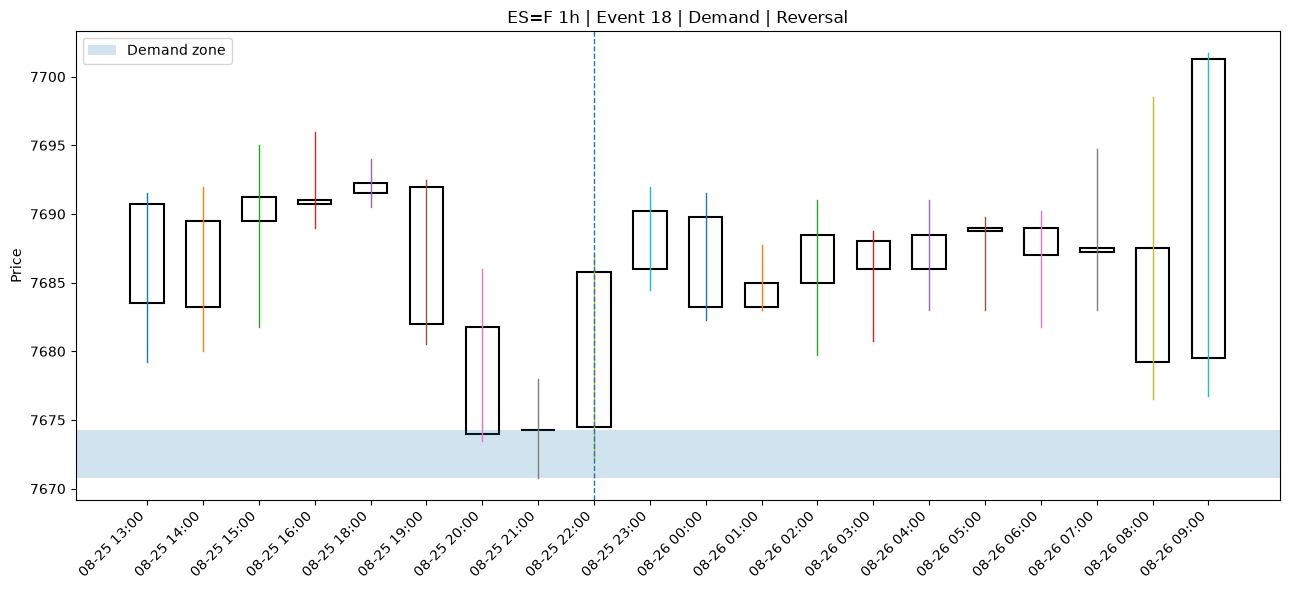

initial_time                 2026-08-25 20:00:00-04:00
consolidation_start          2026-08-25 21:00:00-04:00
consolidation_end            2026-08-25 21:00:00-04:00
second_impulse_time          2026-08-25 22:00:00-04:00
consolidation_bars                                   1
zone_type                                       demand
zone_low                                       7670.75
zone_high                                      7674.25
zone_width                                         3.5
initial_direction                                   -1
second_direction                                     1
relationship                                  reversal
initial_body_ratio                                0.62
second_body_ratio                             0.762712
initial_range                                     12.5
consolidation_range                               7.25
second_body                                      11.25
second_body_zone_multiple                     3.214286
second_pos

In [7]:
EVENT_NUMBER = 18  # valid values are 0 through len(events)-1

event = events.iloc[EVENT_NUMBER]
event_time = event["second_impulse_time"]
loc = df.index.get_loc(event_time)

start = max(0, loc - 8)
end = min(len(df), loc + 12)
window = df.iloc[start:end].copy()

# Create candlestick chart
fig, ax = plt.subplots(figsize=(13, 6))

for x, (_, row) in enumerate(window.iterrows()):
    o, h, l, c = row["Open"], row["High"], row["Low"], row["Close"]

    # Wick
    ax.plot([x, x], [l, h], linewidth=1)

    # Body
    body_bottom = min(o, c)
    body_height = max(abs(c - o), 1e-9)

    ax.add_patch(
        plt.Rectangle(
            (x - 0.30, body_bottom),
            0.60,
            body_height,
            fill=False,
            linewidth=1.5,
        )
    )

# Highlight the IOF zone
ax.axhspan(
    event["zone_low"],
    event["zone_high"],
    alpha=0.20,
    label=f'{event["zone_type"].title()} zone',
)

# Mark the second impulse
second_x = window.index.get_loc(event_time)
ax.axvline(
    second_x,
    linestyle="--",
    linewidth=1
)

# X-axis labels
ax.set_xticks(range(len(window)))
ax.set_xticklabels(
    [idx.strftime("%m-%d %H:%M") for idx in window.index],
    rotation=45,
    ha="right",
)

ax.set_title(
    f'{TICKER} {INTERVAL} | Event {EVENT_NUMBER} | '
    f'{event["zone_type"].title()} | {event["relationship"].title()}'
)

ax.set_ylabel("Price")
ax.legend()

plt.tight_layout()
plt.show()

event

## 5. First Retest Analysis
Here I define what counts as a retest of a zone. After that, I detect and track which zones have been retested and which have not. To do this, we find the first candle **after** the second impulse whose range intersects each IOF zone.

### First Retest Definition
- The first retest is defined as the first future hourly candle whose high-low range intersects the detected IOF zone following the second impulse.
- The retest candle's closing price is used as the reference price.

In [8]:
# ============================================================
# 5. Find the first retest of each IOF zone
# ============================================================

def find_first_retests(df, events, max_bars=50):
    """
    Find the first future candle whose range intersects each IOF zone.

    A retest occurs when:
        candle High >= zone_low
        AND
        candle Low <= zone_high

    Search begins on the candle AFTER the second impulse.

    max_bars:
        Maximum number of candles to search after the second impulse.
        Zones that do not retest within this window are recorded as
        having no retest.
    """

    results = []

    for event_idx, event in events.iterrows():

        second_pos = int(event["second_pos"])

        zone_low = float(event["zone_low"])
        zone_high = float(event["zone_high"])

        first_retest_pos = None

        search_end = min(
            len(df),
            second_pos + 1 + max_bars
        )

        for pos in range(second_pos + 1, search_end):

            candle_high = float(df.iloc[pos]["High"])
            candle_low = float(df.iloc[pos]["Low"])

            # Does this candle's range intersect the zone?
            if candle_high >= zone_low and candle_low <= zone_high:
                first_retest_pos = pos
                break

        result = event.to_dict()

        if first_retest_pos is None:
            result["retest_found"] = False
            result["retest_time"] = pd.NaT
            result["retest_pos"] = np.nan
            result["bars_to_retest"] = np.nan

        else:
            result["retest_found"] = True
            result["retest_time"] = df.index[first_retest_pos]
            result["retest_pos"] = first_retest_pos
            result["bars_to_retest"] = (
                first_retest_pos - second_pos
            )

        results.append(result)

    return pd.DataFrame(results)

In [9]:
retests = find_first_retests(df, events)

print(f"Total IOF zones: {len(retests)}")
print(f"Zones with a retest: {retests['retest_found'].sum()}")
print(f"Zones without a retest: {(~retests['retest_found']).sum()}")

Total IOF zones: 26
Zones with a retest: 21
Zones without a retest: 5


In [10]:
retests[
    [
        "zone_type",
        "relationship",
        "consolidation_bars",
        "second_impulse_time",
        "zone_low",
        "zone_high",
        "retest_found",
        "retest_time",
        "bars_to_retest",
    ]
]

,zone_type,relationship,consolidation_bars,second_impulse_time,zone_low,zone_high,retest_found,retest_time,bars_to_retest
0,demand,reversal,1,2026-06-26 02:00:00-04:00,7364.50,7372.00,True,2026-06-26 09:00:00-04:00,7.0
1,demand,continuation,1,2026-06-30 11:00:00-04:00,7515.50,7526.75,True,2026-06-30 22:00:00-04:00,10.0
2,demand,reversal,1,2026-07-08 19:00:00-04:00,7516.25,7519.00,False,NaT,NaN
3,supply,reversal,1,2026-07-17 08:00:00-04:00,7518.25,7522.00,True,2026-07-17 10:00:00-04:00,2.0
4,demand,reversal,1,2026-07-20 03:00:00-04:00,7491.00,7497.00,True,2026-07-20 14:00:00-04:00,11.0
5,supply,continuation,2,2026-07-22 02:00:00-04:00,7536.25,7539.25,True,2026-07-22 09:00:00-04:00,7.0
6,supply,continuation,1,2026-07-22 15:00:00-04:00,7546.75,7549.75,True,2026-07-22 16:00:00-04:00,1.0
7,supply,continuation,1,2026-07-24 14:00:00-04:00,7469.00,7481.00,True,2026-07-27 09:00:00-04:00,18.0
8,supply,continuation,1,2026-07-27 09:00:00-04:00,7511.75,7515.25,False,NaT,NaN
9,supply,continuation,1,2026-07-29 08:00:00-04:00,7478.00,7484.75,True,2026-07-29 14:00:00-04:00,6.0


## 6. Measure Post-Retest reaction
Now I define and measure the outcome after a zone is retested. For demand zones, a positive return is favorable. For supply zones, a negative return is favorable.

In [11]:
def measure_retest_reactions(df, retests, horizons=(1, 3, 5, 10)):
    results = retests.copy()

    for horizon in horizons:
        raw_returns = []
        directional_returns = []

        for _, event in results.iterrows():

            if not event["retest_found"]:
                raw_returns.append(np.nan)
                directional_returns.append(np.nan)
                continue

            retest_pos = int(event["retest_pos"])
            future_pos = retest_pos + horizon

            if future_pos >= len(df):
                raw_returns.append(np.nan)
                directional_returns.append(np.nan)
                continue

            retest_close = float(df.iloc[retest_pos]["Close"])
            future_close = float(df.iloc[future_pos]["Close"])

            raw_return = (
                future_close - retest_close
            ) / retest_close

            if event["zone_type"] == "demand":
                directional_return = raw_return
            else:
                directional_return = -raw_return

            raw_returns.append(raw_return)
            directional_returns.append(directional_return)

        results[f"return_{horizon}bar"] = raw_returns
        results[f"directional_return_{horizon}bar"] = directional_returns

    return results

In [12]:
reaction_results = measure_retest_reactions(df, retests)

reaction_results[
    [
        "zone_type",
        "relationship",
        "retest_time",
        "bars_to_retest",
        "directional_return_1bar",
        "directional_return_3bar",
        "directional_return_5bar",
        "directional_return_10bar",
    ]
]

,zone_type,relationship,retest_time,bars_to_retest,directional_return_1bar,directional_return_3bar,directional_return_5bar,directional_return_10bar
0,demand,reversal,2026-06-26 09:00:00-04:00,7.0,0.002229,0.004965,0.001013,0.004999
1,demand,continuation,2026-06-30 22:00:00-04:00,10.0,0.000432,-0.000199,-0.000797,-0.000066
2,demand,reversal,NaT,NaN,NaN,NaN,NaN,NaN
3,supply,reversal,2026-07-17 10:00:00-04:00,2.0,-0.002395,0.000732,0.002594,0.002860
4,demand,reversal,2026-07-20 14:00:00-04:00,11.0,-0.000634,-0.002003,0.000234,0.004038
5,supply,continuation,2026-07-22 09:00:00-04:00,7.0,0.001060,-0.001490,0.000397,0.000430
6,supply,continuation,2026-07-22 16:00:00-04:00,1.0,0.002453,-0.000729,0.001359,0.004840
7,supply,continuation,2026-07-27 09:00:00-04:00,18.0,0.002475,0.006155,0.003378,0.004850
8,supply,continuation,NaT,NaN,NaN,NaN,NaN,NaN
9,supply,continuation,2026-07-29 14:00:00-04:00,6.0,0.016722,0.014080,0.013311,0.014280


In [13]:
for horizon in [1, 3, 5, 10]:

    col = f"directional_return_{horizon}bar"

    valid = reaction_results[col].dropna()

    print(f"\n{horizon}-bar reaction")
    print("-" * 30)
    print(f"Sample size: {len(valid)}")
    print(f"Average directional return: {valid.mean():.4%}")
    print(f"Median directional return: {valid.median():.4%}")
    print(f"Positive reaction rate: {(valid > 0).mean():.1%}")


1-bar reaction
------------------------------
Sample size: 21
Average directional return: 0.1221%
Median directional return: 0.0228%
Positive reaction rate: 66.7%

3-bar reaction
------------------------------
Sample size: 21
Average directional return: 0.1508%
Median directional return: 0.0417%
Positive reaction rate: 61.9%

5-bar reaction
------------------------------
Sample size: 21
Average directional return: 0.2066%
Median directional return: 0.1013%
Positive reaction rate: 71.4%

10-bar reaction
------------------------------
Sample size: 21
Average directional return: 0.2377%
Median directional return: 0.1065%
Positive reaction rate: 71.4%


## 7. Analyze Retest Results
Before doing any statistical testing, I sort the data and analyze if a certain type of zone is performing better than another and whether results are being skewed by a few substantial winners.

In [14]:
reaction_results[
    [
        "zone_type",
        "relationship",
        "consolidation_bars",
        "retest_time",
        "bars_to_retest",
        "directional_return_1bar",
        "directional_return_3bar",
        "directional_return_5bar",
        "directional_return_10bar",
    ]
].sort_values("retest_time")

,zone_type,relationship,consolidation_bars,retest_time,bars_to_retest,directional_return_1bar,directional_return_3bar,directional_return_5bar,directional_return_10bar
0,demand,reversal,1,2026-06-26 09:00:00-04:00,7.0,0.002229,0.004965,0.001013,0.004999
1,demand,continuation,1,2026-06-30 22:00:00-04:00,10.0,0.000432,-0.000199,-0.000797,-0.000066
3,supply,reversal,1,2026-07-17 10:00:00-04:00,2.0,-0.002395,0.000732,0.002594,0.002860
4,demand,reversal,1,2026-07-20 14:00:00-04:00,11.0,-0.000634,-0.002003,0.000234,0.004038
5,supply,continuation,2,2026-07-22 09:00:00-04:00,7.0,0.001060,-0.001490,0.000397,0.000430
6,supply,continuation,1,2026-07-22 16:00:00-04:00,1.0,0.002453,-0.000729,0.001359,0.004840
7,supply,continuation,1,2026-07-27 09:00:00-04:00,18.0,0.002475,0.006155,0.003378,0.004850
9,supply,continuation,1,2026-07-29 14:00:00-04:00,6.0,0.016722,0.014080,0.013311,0.014280
10,demand,continuation,1,2026-07-30 11:00:00-04:00,2.0,0.002593,0.004984,0.006734,0.009226
11,supply,reversal,1,2026-07-31 03:00:00-04:00,1.0,-0.000833,-0.000000,0.003164,0.000100


### 7.1 Continuation vs. Reversal

In [15]:
for relationship in ["reversal", "continuation"]:

    subset = reaction_results[
        (reaction_results["relationship"] == relationship)
        & (reaction_results["retest_found"])
    ]

    print(f"\n{relationship.upper()}")
    print("-" * 30)
    print(f"Sample size: {len(subset)}")

    for horizon in [1, 3, 5, 10]:

        col = f"directional_return_{horizon}bar"

        valid = subset[col].dropna()

        if len(valid) > 0:
            print(
                f"{horizon}h: "
                f"mean={valid.mean():.4%}, "
                f"positive={((valid > 0).mean()):.1%}"
            )


REVERSAL
------------------------------
Sample size: 8
1h: mean=-0.0130%, positive=37.5%
3h: mean=0.0735%, positive=62.5%
5h: mean=0.2089%, positive=87.5%
10h: mean=0.2735%, positive=87.5%

CONTINUATION
------------------------------
Sample size: 13
1h: mean=0.2053%, positive=84.6%
3h: mean=0.1984%, positive=61.5%
5h: mean=0.2053%, positive=61.5%
10h: mean=0.2156%, positive=61.5%


### 7.2 Supply vs. Demand

In [16]:
for zone_type in ["demand", "supply"]:

    subset = reaction_results[
        (reaction_results["zone_type"] == zone_type)
        & (reaction_results["retest_found"])
    ]

    print(f"\n{zone_type.upper()}")
    print("-" * 30)
    print(f"Sample size: {len(subset)}")

    for horizon in [1, 3, 5, 10]:

        col = f"directional_return_{horizon}bar"
        valid = subset[col].dropna()

        if len(valid) > 0:
            print(
                f"{horizon}h: "
                f"mean={valid.mean():.4%}, "
                f"median={valid.median():.4%}, "
                f"positive={(valid > 0).mean():.1%}"
            )


DEMAND
------------------------------
Sample size: 8
1h: mean=0.0620%, median=0.0313%, positive=62.5%
3h: mean=0.0757%, median=0.0207%, positive=50.0%
5h: mean=0.1390%, median=0.0068%, positive=50.0%
10h: mean=0.2277%, median=0.2374%, positive=62.5%

SUPPLY
------------------------------
Sample size: 13
1h: mean=0.1591%, median=0.0228%, positive=69.2%
3h: mean=0.1971%, median=0.0417%, positive=69.2%
5h: mean=0.2483%, median=0.1742%, positive=84.6%
10h: mean=0.2438%, median=0.1065%, positive=76.9%


## 8. MFE & MAE Analysis
Now I calculate the MFE (Maximum Favorable Excursion) and MAE (Maximum Adverse Excursion)

- MFE represents the maximum favorable excursion in the expected direction,
while MAE represents the maximum adverse excursion.

In [17]:
def measure_mfe_mae(df, retests, horizons=(1, 3, 5, 10)):
    results = retests.copy()

    for horizon in horizons:

        mfe_values = []
        mae_values = []

        for _, event in results.iterrows():

            if not event["retest_found"]:
                mfe_values.append(np.nan)
                mae_values.append(np.nan)
                continue

            retest_pos = int(event["retest_pos"])
            future_end = retest_pos + horizon

            if future_end >= len(df):
                mfe_values.append(np.nan)
                mae_values.append(np.nan)
                continue

            retest_close = float(df.iloc[retest_pos]["Close"])

            future = df.iloc[
                retest_pos + 1 : future_end + 1
            ]

            if len(future) == 0:
                mfe_values.append(np.nan)
                mae_values.append(np.nan)
                continue

            highest_price = float(future["High"].max())
            lowest_price = float(future["Low"].min())

            upside = (highest_price - retest_close) / retest_close
            downside = (lowest_price - retest_close) / retest_close

            if event["zone_type"] == "demand":
                mfe = upside
                mae = downside

            else:
                mfe = -downside
                mae = -upside

            mfe_values.append(mfe)
            mae_values.append(mae)

        results[f"mfe_{horizon}bar"] = mfe_values
        results[f"mae_{horizon}bar"] = mae_values

    return results
    
mfe_mae_results = measure_mfe_mae(df, reaction_results)

In [18]:
mfe_mae_results[
    [
        "zone_type",
        "relationship",
        "retest_time",
        "mfe_1bar",
        "mae_1bar",
        "mfe_3bar",
        "mae_3bar",
        "mfe_5bar",
        "mae_5bar",
        "mfe_10bar",
        "mae_10bar",
    ]
]

,zone_type,relationship,retest_time,mfe_1bar,mae_1bar,mfe_3bar,mae_3bar,mfe_5bar,mae_5bar,mfe_10bar,mae_10bar
0,demand,reversal,2026-06-26 09:00:00-04:00,0.004695,-0.000372,0.007836,-0.000372,0.007836,-0.000372,0.007836,-0.004459
1,demand,continuation,2026-06-30 22:00:00-04:00,0.000664,-0.000365,0.000764,-0.000398,0.000764,-0.002457,0.001428,-0.002457
2,demand,reversal,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,supply,reversal,2026-07-17 10:00:00-04:00,0.001530,-0.002694,0.001530,-0.002960,0.003991,-0.002960,0.004557,-0.002960
4,demand,reversal,2026-07-20 14:00:00-04:00,0.000901,-0.001669,0.000901,-0.002336,0.000901,-0.002336,0.004439,-0.002336
5,supply,continuation,2026-07-22 09:00:00-04:00,0.002782,-0.000861,0.002782,-0.001821,0.002782,-0.001821,0.004503,-0.001821
6,supply,continuation,2026-07-22 16:00:00-04:00,0.003348,0.000663,0.003348,-0.001094,0.003348,-0.001127,0.006067,-0.001127
7,supply,continuation,2026-07-27 09:00:00-04:00,0.006824,-0.000702,0.007058,-0.000702,0.007727,-0.000702,0.007727,-0.000702
8,supply,continuation,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,supply,continuation,2026-07-29 14:00:00-04:00,0.017324,-0.000903,0.020233,-0.000903,0.020233,-0.000903,0.020233,-0.000903


In [19]:
for horizon in [1, 3, 5, 10]:

    mfe_col = f"mfe_{horizon}bar"
    mae_col = f"mae_{horizon}bar"

    mfe = mfe_mae_results[mfe_col].dropna()
    mae = mfe_mae_results[mae_col].dropna()

    print(f"\n{horizon}-bar MFE / MAE")
    print("-" * 30)

    print(f"MFE mean:   {mfe.mean():.4%}")
    print(f"MFE median: {mfe.median():.4%}")

    print(f"MAE mean:   {mae.mean():.4%}")
    print(f"MAE median: {mae.median():.4%}")


1-bar MFE / MAE
------------------------------
MFE mean:   0.2506%
MFE median: 0.1367%
MAE mean:   -0.0733%
MAE median: -0.0419%

3-bar MFE / MAE
------------------------------
MFE mean:   0.3447%
MFE median: 0.2470%
MAE mean:   -0.1243%
MAE median: -0.1094%

5-bar MFE / MAE
------------------------------
MFE mean:   0.4305%
MFE median: 0.3223%
MAE mean:   -0.1397%
MAE median: -0.1365%

10-bar MFE / MAE
------------------------------
MFE mean:   0.5269%
MFE median: 0.4503%
MAE mean:   -0.1799%
MAE median: -0.1465%


## 9. Control / Baseline
Now I create random baseline samples using the same number and same Supply/Demand proportions of the observed IOF retests. This is done to observe if IOF has a meaningful statistical difference from entering the market at random.

In [20]:
def generate_random_baseline(
    df,
    reaction_results,
    simulations=10000,
    horizons=(1, 3, 5, 10),
    seed=42,
):
    """
    Methodology:
    - Same number of observations as the actual retests
    - Same Demand/Supply proportions
    - Random observation times
    - Observations sampled without replacement
    - Random Demand/Supply assignment
    """

    valid_results = reaction_results[
        reaction_results["retest_found"]
    ]

    n_events = len(valid_results)

    n_demand = (
        valid_results["zone_type"] == "demand"
    ).sum()

    n_supply = (
        valid_results["zone_type"] == "supply"
    ).sum()

    max_horizon = max(horizons)

    closes = df["Close"].to_numpy(dtype=float)

    eligible_positions = np.arange(
        0,
        len(df) - max_horizon
    )

    rng = np.random.default_rng(seed)

    results = {}

    # ---------------------------------------------------------
    # Random positions
    # ---------------------------------------------------------
    #
    # Generate random rankings for every simulation/event.
    # Taking the smallest n_events gives sampling without
    # replacement within each simulation.
    #

    random_keys = rng.random(
        (simulations, len(eligible_positions))
    )

    positions = np.argpartition(
        random_keys,
        n_events - 1,
        axis=1
    )[:, :n_events]

    positions = eligible_positions[positions]

    # ---------------------------------------------------------
    # Random Demand/Supply directions
    # ---------------------------------------------------------

    directions = np.concatenate([
        np.ones(n_demand),
        -np.ones(n_supply)
    ])

    direction_keys = rng.random(
        (simulations, n_events)
    )

    direction_order = np.argsort(
        direction_keys,
        axis=1
    )

    directions_matrix = np.empty(
        (simulations, n_events)
    )

    for sim in range(simulations):
        directions_matrix[sim] = (
            directions[direction_order[sim]]
        )

    # ---------------------------------------------------------
    # Calculate returns
    # ---------------------------------------------------------

    for horizon in horizons:

        current_prices = closes[positions]

        future_prices = closes[
            positions + horizon
        ]

        raw_returns = (
            future_prices - current_prices
        ) / current_prices

        directional_returns = (
            raw_returns * directions_matrix
        )

        simulation_means = (
            directional_returns.mean(axis=1)
        )

        results[horizon] = simulation_means

    return pd.DataFrame(results)

In [21]:
random_baseline_results = generate_random_baseline(
    df,
    reaction_results,
    simulations=10000,
    horizons=(1, 3, 5, 10),
    seed=42,
)

random_baseline_results.describe()

,1,3,5,10
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.000006,-0.000024,-0.000043,-0.000098
std,0.000319,0.000538,0.000667,0.000936
min,-0.001230,-0.002277,-0.002520,-0.003551
25%,-0.000208,-0.000377,-0.000491,-0.000732
50%,-0.000007,-0.000023,-0.000036,-0.000100
75%,0.000197,0.000338,0.000404,0.000533
max,0.001646,0.002399,0.003039,0.004384


## 10. Statistical Significance
Now compare the results to calculate whether IOF's results are significantly different from random.

In [22]:
def calculate_empirical_pvalues(reaction_results, baseline):
    results = []

    for horizon in [1, 3, 5, 10]:

        col = f"directional_return_{horizon}bar"

        observed = reaction_results[
            reaction_results["retest_found"]
        ][col].dropna().mean()

        # Baseline is now a DataFrame.
        random_values = baseline[horizon]

        count_at_least_as_extreme = (
            random_values >= observed
        ).sum()

        p_value = (
            count_at_least_as_extreme + 1
        ) / (
            len(random_values) + 1
        )

        results.append({
            "horizon": horizon,
            "observed_mean": observed,
            "random_mean": random_values.mean(),
            "random_std": random_values.std(),
            "p_value": p_value,
        })

    return pd.DataFrame(results)

In [23]:
significance = calculate_empirical_pvalues(
    reaction_results,
    random_baseline_results
)

significance

,horizon,observed_mean,random_mean,random_std,p_value
0,1,0.001221,-0.000006,0.000319,0.0011
1,3,0.001508,-0.000024,0.000538,0.0023
2,5,0.002066,-0.000043,0.000667,0.0011
3,10,0.002377,-0.000098,0.000936,0.0041


## 11. Matched Baseline - *Initial Attempt*
The results from the first control test were promising, but the baseline was sampled from random 1h bars. In this test, I will see if I get similar results while using a random baseline that occurs under similar market conditions determined by factors such as:
- Direction
- Time of day
- Recent volatility

In [24]:
# Calculate recent volatility for each hourly bar.
# We use the absolute percentage change over the previous 5 bars.

df_matched = df.copy()

df_matched["Return"] = df_matched["Close"].pct_change()

df_matched["RecentVolatility"] = (
    df_matched["Return"]
    .rolling(5)
    .std()
)

df_matched["Hour"] = df_matched.index.hour

In [43]:
def generate_matched_baseline(
    df,
    reaction_results,
    simulations=10000,
    horizons=(1, 3, 5, 10),
    seed=42,
):
    """
    Methodology:

    - Same Demand/Supply direction
    - Same hour of day
    - Similar recent 5-bar volatility
    - Closest 20% volatility matches
    - Controls cannot be reused within a simulation
    """

    rng = np.random.default_rng(seed)

    data = df.copy()

    data["Return"] = data["Close"].pct_change()

    data["RecentVolatility"] = (
        data["Return"]
        .rolling(5)
        .std()
    )

    data["Hour"] = data.index.hour

    closes = data["Close"].to_numpy(dtype=float)
    volatility = data["RecentVolatility"].to_numpy()
    hours = data["Hour"].to_numpy()

    max_horizon = max(horizons)

    valid_results = reaction_results[
        reaction_results["retest_found"]
    ].copy()

    # ---------------------------------------------------------
    # Precompute candidate pools
    # ---------------------------------------------------------

    event_data = []

    eligible_positions = np.arange(
        5,
        len(data) - max_horizon
    )

    for _, event in valid_results.iterrows():

        retest_pos = int(event["retest_pos"])

        target_hour = hours[retest_pos]
        target_vol = volatility[retest_pos]

        if np.isnan(target_vol):
            continue

        # Same-hour eligible observations
        candidates = eligible_positions[
            hours[eligible_positions] == target_hour
        ]

        # Remove the actual IOF retest
        candidates = candidates[
            candidates != retest_pos
        ]

        if len(candidates) == 0:
            continue

        candidates = candidates[
            ~np.isnan(volatility[candidates])
        ]

        if len(candidates) == 0:
            continue

        # -----------------------------------------------------
        # Closest 20% by volatility
        # -----------------------------------------------------

        distances = np.abs(
            volatility[candidates]
            - target_vol
        )

        n_candidates = max(
            1,
            int(len(candidates) * 0.20)
        )

        closest_indices = np.argpartition(
            distances,
            n_candidates - 1
        )[:n_candidates]

        candidates = candidates[
            closest_indices
        ]

        direction = (
            1
            if event["zone_type"] == "demand"
            else -1
        )

        event_data.append({
            "direction": direction,
            "candidates": candidates,
        })

    results = {
        horizon: []
        for horizon in horizons
    }

    # ---------------------------------------------------------
    # Run simulations
    # ---------------------------------------------------------

    for _ in range(simulations):

        used_positions = set()

        simulation_returns = {
            horizon: []
            for horizon in horizons
        }

        for event in event_data:

            candidates = event["candidates"]

            # Remove controls already used
            available = [
                pos
                for pos in candidates
                if pos not in used_positions
            ]

            if len(available) == 0:
                break

            # Random control
            control_pos = available[
                rng.integers(len(available))
            ]

            used_positions.add(
                int(control_pos)
            )

            current_close = closes[
                control_pos
            ]

            for horizon in horizons:

                future_close = closes[
                    control_pos + horizon
                ]

                raw_return = (
                    future_close - current_close
                ) / current_close

                directional_return = (
                    raw_return
                    * event["direction"]
                )

                simulation_returns[
                    horizon
                ].append(
                    directional_return
                )

        # Only retain complete simulations
        for horizon in horizons:

            values = simulation_returns[horizon]

            if len(values) == len(event_data):

                results[horizon].append(
                    np.mean(values)
                )

    return pd.DataFrame(results)

In [26]:
matched_baseline = generate_matched_baseline(
    df,
    reaction_results,
    simulations=10000
)

matched_baseline.head()

,1,3,5,10
0,0.000289,-0.000704,-0.000858,-0.000911
1,-0.000141,-0.000246,0.000058,-0.000551
2,-0.000019,-0.001088,-0.001796,-0.001601
3,-0.000021,-0.000255,-0.000462,-0.001566
4,0.000152,-0.000236,-0.000713,-0.000257


In [27]:
for horizon in [1, 3, 5, 10]:

    values = matched_baseline[horizon]

    print(f"\n{horizon}-bar matched baseline")
    print("-" * 40)

    print(f"Mean:   {values.mean():.4%}")
    print(f"Median: {values.median():.4%}")
    print(f"Std:    {values.std():.4%}")
    print(
        f"Positive simulations: "
        f"{(values > 0).mean():.1%}"
    )


1-bar matched baseline
----------------------------------------
Mean:   -0.0100%
Median: -0.0094%
Std:    0.0291%
Positive simulations: 36.7%

3-bar matched baseline
----------------------------------------
Mean:   -0.0571%
Median: -0.0564%
Std:    0.0529%
Positive simulations: 14.2%

5-bar matched baseline
----------------------------------------
Mean:   -0.0635%
Median: -0.0630%
Std:    0.0608%
Positive simulations: 15.3%

10-bar matched baseline
----------------------------------------
Mean:   -0.0904%
Median: -0.0900%
Std:    0.0807%
Positive simulations: 13.3%


### Methodological Note

The initial matched baseline matched observations based on hour and recent
volatility but independently randomized directional assignments.

This approach may introduce directional bias because the direction of
the control observation is not paired with the direction of its
corresponding IOF retest.

A paired matched-control design is therefore used below as the primary
matched analysis.

## 12. Paired Match Control

Now generate paired matched controls for each IOF retest. Each control is matched to its corresponding IOF event on:
- Hour of day
- Recent 5-bar volatility
- Same directional position (long for demand, short for supply)

Controls are selected from historical observations before the corresponding IOF retest to avoid using future information.

In [28]:
def generate_paired_matched_control(
    df,
    reaction_results,
    simulations=10000,
    horizons=(1, 3, 5, 10),
    seed=42,
):

    rng = np.random.default_rng(seed)

    data = df.copy()

    data["Return"] = data["Close"].pct_change()

    data["RecentVolatility"] = (
        data["Return"]
        .rolling(5)
        .std()
    )

    data["Hour"] = data.index.hour

    closes = data["Close"].to_numpy(dtype=float)
    volatility = data["RecentVolatility"].to_numpy()
    hours = data["Hour"].to_numpy()

    max_horizon = max(horizons)

    valid_results = reaction_results[
        reaction_results["retest_found"]
    ].copy()

    valid_results["retest_pos"] = (
        valid_results["retest_pos"].astype(int)
    )

    # ---------------------------------------------------------
    # Find matchable events and precompute candidate pools
    # ---------------------------------------------------------

    event_data = []
    matchable_event_indices = []
    
    for event_index, event in valid_results.iterrows():
    
        retest_pos = int(event["retest_pos"])
    
        target_hour = hours[retest_pos]
        target_vol = volatility[retest_pos]
    
        if np.isnan(target_vol):
            continue
    
        historical_end = min(
            retest_pos,
            len(data) - max_horizon
        )
    
        candidate_positions = np.arange(
            5,
            historical_end
        )
    
        candidate_positions = candidate_positions[
            hours[candidate_positions] == target_hour
        ]
    
        candidate_positions = candidate_positions[
            ~np.isnan(
                volatility[candidate_positions]
            )
        ]
    
        if len(candidate_positions) == 0:
            continue
    
        distances = np.abs(
            volatility[candidate_positions]
            - target_vol
        )
    
        n_candidates = max(
            1,
            int(len(candidate_positions) * 0.20)
        )
    
        closest_indices = np.argpartition(
            distances,
            n_candidates - 1
        )[:n_candidates]
    
        candidate_positions = (
            candidate_positions[closest_indices]
        )
    
        direction = (
            1
            if event["zone_type"] == "demand"
            else -1
        )
    
        matchable_event_indices.append(event_index)
    
        event_data.append({
            "event_index": event_index,
            "direction": direction,
            "candidates": candidate_positions,
        })

    print(
        f"IOF retests available: "
        f"{len(valid_results)}"
    )

    print(
        f"IOF retests with valid controls: "
        f"{len(event_data)}"
    )

    print(
        f"IOF retests excluded: "
        f"{len(valid_results) - len(event_data)}"
    )

    results = {}

    # ---------------------------------------------------------
    # Simulations
    # ---------------------------------------------------------

    for horizon in horizons:

        simulation_means = np.empty(
            simulations
        )

        for sim in range(simulations):

            returns = []

            for event in event_data:

                candidates = event["candidates"]

                # Randomly choose a control
                control_pos = candidates[
                    rng.integers(len(candidates))
                ]

                current_close = closes[
                    control_pos
                ]

                future_close = closes[
                    control_pos + horizon
                ]

                raw_return = (
                    future_close - current_close
                ) / current_close

                directional_return = (
                    raw_return
                    * event["direction"]
                )

                returns.append(
                    directional_return
                )

            simulation_means[sim] = np.mean(
                returns
            )

        results[horizon] = simulation_means

    return pd.DataFrame(results), matchable_event_indices


In [29]:
paired_baseline, paired_event_indices = generate_paired_matched_control(
    df,
    reaction_results,
    simulations=10000,
)

IOF retests available: 21
IOF retests with valid controls: 20
IOF retests excluded: 1


## 13. Paired Control Results

In [30]:
valid_results = reaction_results.loc[paired_event_indices]

for horizon in [1, 3, 5, 10]:

    control_values = paired_baseline[horizon]

    actual_col = f"directional_return_{horizon}bar"
    iof_mean = valid_results[actual_col].mean()

    differences = iof_mean - control_values

    print(f"\n{horizon}-bar paired control")
    print("-" * 40)

    print(f"IOF mean:              {iof_mean:.4%}")
    print(f"Control mean:          {control_values.mean():.4%}")
    print(f"Mean IOF - Control:    {differences.mean():.4%}")
    print(f"Median IOF - Control:  {differences.median():.4%}")
    print(f"Std:                   {differences.std():.4%}")
    print(
        f"IOF outperformed control: "
        f"{(differences > 0).mean():.1%}"
    )


1-bar paired control
----------------------------------------
IOF mean:              0.1171%
Control mean:          0.0090%
Mean IOF - Control:    0.1081%
Median IOF - Control:  0.1082%
Std:                   0.0298%
IOF outperformed control: 100.0%

3-bar paired control
----------------------------------------
IOF mean:              0.1335%
Control mean:          -0.0348%
Mean IOF - Control:    0.1683%
Median IOF - Control:  0.1712%
Std:                   0.0674%
IOF outperformed control: 99.2%

5-bar paired control
----------------------------------------
IOF mean:              0.2119%
Control mean:          -0.0320%
Mean IOF - Control:    0.2439%
Median IOF - Control:  0.2444%
Std:                   0.0710%
IOF outperformed control: 100.0%

10-bar paired control
----------------------------------------
IOF mean:              0.2246%
Control mean:          -0.1137%
Mean IOF - Control:    0.3382%
Median IOF - Control:  0.3384%
Std:                   0.0827%
IOF outperformed control: 

In [31]:
# Examine the actual IOF vs. matched-control differences
# for one representative simulation.

test_control, _ = generate_paired_matched_control(
    df,
    reaction_results,
    simulations=1,
    seed=42
)

print(test_control)

IOF retests available: 21
IOF retests with valid controls: 20
IOF retests excluded: 1
         1         3         5         10
0  0.000493  0.000309 -0.000857 -0.001913


## 14. Paired Control Event-Level Audit

The paired-control results showed strong outperformance by
IOF retests. Before interpreting this as evidence of a genuine effect,
I will inspect the individual event-level differences.

This audit is intended to determine whether the aggregate result is
driven by a small number of observations or is broadly consistent
across the sample.

In [32]:
def get_paired_control_events(
    df,
    reaction_results,
    horizons=(1, 3, 5, 10),
    seed=42,
):

    rng = np.random.default_rng(seed)

    data = df.copy()

    # Recent volatility
    data["Return"] = data["Close"].pct_change()
    data["RecentVolatility"] = (
        data["Return"]
        .rolling(5)
        .std()
    )

    data["Hour"] = data.index.hour

    closes = data["Close"].to_numpy(dtype=float)
    volatility = data["RecentVolatility"].to_numpy()
    hours = data["Hour"].to_numpy()

    max_horizon = max(horizons)

    valid_results = reaction_results[
        reaction_results["retest_found"]
    ].copy()

    valid_results["retest_pos"] = (
        valid_results["retest_pos"].astype(int)
    )

    paired_events = []

    for event_idx, event in valid_results.iterrows():

        retest_pos = int(event["retest_pos"])

        target_hour = hours[retest_pos]
        target_vol = volatility[retest_pos]

        if np.isnan(target_vol):
            continue

        # ---------------------------------------------------------
        # Historical observations only
        # ---------------------------------------------------------

        historical_end = min(
            retest_pos,
            len(data) - max_horizon
        )

        candidate_positions = np.arange(
            5,
            historical_end
        )

        # Same hour
        candidate_positions = candidate_positions[
            hours[candidate_positions] == target_hour
        ]

        # Valid volatility
        candidate_positions = candidate_positions[
            ~np.isnan(
                volatility[candidate_positions]
            )
        ]

        if len(candidate_positions) == 0:
            continue

        # ---------------------------------------------------------
        # Match by recent volatility
        # ---------------------------------------------------------

        distances = np.abs(
            volatility[candidate_positions]
            - target_vol
        )

        n_candidates = max(
            1,
            int(len(candidate_positions) * 0.20)
        )

        closest_indices = np.argpartition(
            distances,
            n_candidates - 1
        )[:n_candidates]

        candidate_positions = (
            candidate_positions[closest_indices]
        )

        # ---------------------------------------------------------
        # Direction
        # ---------------------------------------------------------

        direction = (
            1
            if event["zone_type"] == "demand"
            else -1
        )

        # ---------------------------------------------------------
        # Randomly select one matched control
        # ---------------------------------------------------------

        control_pos = candidate_positions[
            rng.integers(len(candidate_positions))
        ]

        # ---------------------------------------------------------
        # Build event record
        # ---------------------------------------------------------

        event_data = {
            "event_idx": event_idx,
            "zone_type": event["zone_type"],
            "relationship": event["relationship"],
            "retest_time": df.index[retest_pos],
            "control_time": df.index[control_pos],
            "direction": direction,
        }

        # ---------------------------------------------------------
        # Calculate IOF vs control returns
        # ---------------------------------------------------------

        for horizon in horizons:

            if retest_pos + horizon >= len(df):
                continue

            if control_pos + horizon >= len(df):
                continue

            # IOF return
            iof_raw = (
                closes[retest_pos + horizon]
                - closes[retest_pos]
            ) / closes[retest_pos]

            # Control return
            control_raw = (
                closes[control_pos + horizon]
                - closes[control_pos]
            ) / closes[control_pos]

            # Convert to directional return
            iof_directional = (
                iof_raw * direction
            )

            control_directional = (
                control_raw * direction
            )

            difference = (
                iof_directional
                - control_directional
            )

            event_data[f"iof_{horizon}bar"] = (
                iof_directional
            )

            event_data[f"control_{horizon}bar"] = (
                control_directional
            )

            event_data[f"difference_{horizon}bar"] = (
                difference
            )

        paired_events.append(event_data)

    return pd.DataFrame(paired_events)

In [33]:
paired_events = get_paired_control_events(
    df,
    retests,
    horizons=(1, 3, 5, 10),
    seed=42,
)

paired_events[
    [
        "event_idx",
        "zone_type",
        "relationship",
        "retest_time",
        "control_time",
        "iof_1bar",
        "control_1bar",
        "difference_1bar",
    ]
].sort_values("difference_1bar")

,event_idx,zone_type,relationship,retest_time,control_time,iof_1bar,control_1bar,difference_1bar
13,16,supply,continuation,2026-08-19 08:00:00-04:00,2026-07-29 08:00:00-04:00,0.001129,0.004489,-0.003359
3,5,supply,continuation,2026-07-22 09:00:00-04:00,2026-07-02 09:00:00-04:00,0.001060,0.004151,-0.003091
2,4,demand,reversal,2026-07-20 14:00:00-04:00,2026-07-15 14:00:00-04:00,-0.000634,0.001940,-0.002574
11,14,demand,continuation,2026-08-14 10:00:00-04:00,2026-07-21 10:00:00-04:00,-0.000672,0.000996,-0.001668
8,11,supply,reversal,2026-07-31 03:00:00-04:00,2026-07-14 03:00:00-04:00,-0.000833,0.000628,-0.001461
14,17,supply,reversal,2026-08-24 07:00:00-04:00,2026-07-16 07:00:00-04:00,0.000228,0.001415,-0.001187
10,13,supply,continuation,2026-08-11 16:00:00-04:00,2026-07-27 16:00:00-04:00,0.000064,0.001207,-0.001143
0,1,demand,continuation,2026-06-30 22:00:00-04:00,2026-06-29 22:00:00-04:00,0.000432,0.001468,-0.001037
17,20,supply,continuation,2026-08-28 15:00:00-04:00,2026-08-06 15:00:00-04:00,0.000097,0.000549,-0.000452
18,21,supply,continuation,2026-08-31 08:00:00-04:00,2026-06-29 08:00:00-04:00,0.000552,0.000737,-0.000184


### Audit Results
The results provide suggestive evidence that first retests of the defined IOF zones may exhibit positive directional reactions relative to matched control observations. However, the effect is not consistently observed at the individual-event level, and the sample is too small to establish statistical significance or robustness.

## 15. Matched Placebo Test

To evaluate whether the observed IOF reaction is unusual relative to
comparable non-IOF market observations, I construct matched placebo
samples.

For each IOF retest, placebo observations are selected from historical
non-IOF observations with similar time-of-day and recent volatility.

The actual IOF event's directional label is preserved when calculating
placebo returns.

Repeated random sampling from these matched placebo pools produces a
Monte Carlo null distribution for the average directional return.

### 15.1 Constructing Matched Placebo Pools

I construct placebo observations from non-IOF market observations that
are comparable to the actual IOF retests.

For each IOF retest, eligible placebo observations must:

- occur before the actual IOF retest;
- occur at the same hour of the day;
- have sufficient future data for the requested horizon;
- have a similar recent volatility environment;
- not themselves be an IOF retest.

The purpose is to determine whether the observed IOF reaction is unusual
relative to comparable observations that were not identified as IOF
retests.

In [34]:
def build_placebo_pools(
    df,
    retests,
    vol_window=5,
    max_horizon=10,
    exclude_bars=10,
):

    data = df.copy()

    data["ret_vol"] = (
        data["Close"]
        .pct_change()
        .rolling(vol_window)
        .std()
    )

    # Positions of actual IOF retests
    actual_retest_positions = set(
        retests.loc[
            retests["retest_found"],
            "retest_pos"
        ].dropna().astype(int)
    )

    pools = {}

    for event_idx, event in retests.iterrows():

        if not event["retest_found"]:
            continue

        actual_pos = int(event["retest_pos"])
        actual_time = df.index[actual_pos]

        actual_vol = data.iloc[actual_pos]["ret_vol"]

        if pd.isna(actual_vol):
            continue

        candidates = []

        # Controls must have enough future data
        latest_control_pos = len(df) - max_horizon - 1

        for pos in range(vol_window, actual_pos):

            # Don't use another IOF retest
            if pos in actual_retest_positions:
                continue

            # Keep controls separated from the actual event
            if actual_pos - pos <= exclude_bars:
                continue

            candidate_time = df.index[pos]

            # Same hour of day
            if candidate_time.hour != actual_time.hour:
                continue

            candidate_vol = data.iloc[pos]["ret_vol"]

            if pd.isna(candidate_vol):
                continue

            # Must have enough future bars
            if pos + max_horizon >= len(df):
                continue

            candidates.append({
                "pos": pos,
                "time": candidate_time,
                "vol": candidate_vol,
                "vol_distance": abs(
                    candidate_vol - actual_vol
                ),
            })

        pools[event_idx] = pd.DataFrame(candidates)

    return pools

In [35]:
placebo_pools = build_placebo_pools(
    df,
    retests,
    vol_window=5,
    max_horizon=10,
    exclude_bars=10,
)
for event_idx, pool in placebo_pools.items():

    event = retests.loc[event_idx]

    print(
        f"Event {event_idx}: "
        f"{event['retest_time']} | "
        f"{event['zone_type']} | "
        f"{event['relationship']} | "
        f"{len(pool)} eligible controls"
    )

Event 0: 2026-06-26 09:00:00-04:00 | demand | reversal | 0 eligible controls
Event 1: 2026-06-30 22:00:00-04:00 | demand | continuation | 2 eligible controls
Event 3: 2026-07-17 10:00:00-04:00 | supply | reversal | 14 eligible controls
Event 4: 2026-07-20 14:00:00-04:00 | demand | reversal | 15 eligible controls
Event 5: 2026-07-22 09:00:00-04:00 | supply | continuation | 16 eligible controls
Event 6: 2026-07-22 16:00:00-04:00 | supply | continuation | 17 eligible controls
Event 7: 2026-07-27 09:00:00-04:00 | supply | continuation | 18 eligible controls
Event 9: 2026-07-29 14:00:00-04:00 | supply | continuation | 21 eligible controls
Event 10: 2026-07-30 11:00:00-04:00 | demand | continuation | 23 eligible controls
Event 11: 2026-07-31 03:00:00-04:00 | supply | reversal | 23 eligible controls
Event 12: 2026-08-11 06:00:00-04:00 | supply | reversal | 31 eligible controls
Event 13: 2026-08-11 16:00:00-04:00 | supply | continuation | 30 eligible controls
Event 14: 2026-08-14 10:00:00-04:0

In [36]:
pool_sizes = pd.Series({
    event_idx: len(pool)
    for event_idx, pool in placebo_pools.items()
    if len(pool) > 0
})

print("Number of actually matchable IOF events:", len(pool_sizes))
print()
print(pool_sizes.describe())

Number of actually matchable IOF events: 20

count    20.000000
mean     28.700000
std      12.798437
min       2.000000
25%      17.750000
50%      30.500000
75%      40.250000
max      49.000000
dtype: float64


In [37]:
placebo_pools[1].sort_values("vol_distance")

,pos,time,vol,vol_distance
1,44,2026-06-29 22:00:00-04:00,0.000629,0.000151
0,21,2026-06-28 22:00:00-04:00,0.002150,0.001370


### Note
The difference in eligible controls between events presents a challenge for the permutation test that will have to be accounted for. As shown above, Event 0 cannot be included because of no eligible controls and Event 1 has only 2 options. This is a result of there not being enough data before their occurrence in the small time period we are testing in. 

### 15.2 Monte Carlo Placebo Test

For each matchable IOF retest, one placebo observation is randomly
selected from the closest 20% of eligible historical observations based
on recent volatility.

The placebo observations are matched by time of day and volatility while
preserving the actual IOF event's directional label.

This process is repeated 10,000 times to create a null distribution of
average directional returns.

The empirical p-value is calculated as the proportion of placebo samples
whose average directional return is at least as large as the observed
IOF average directional return.

In [38]:
def run_placebo_test(
    df,
    retests,
    placebo_pools,
    horizons=(1, 3, 5, 10),
    n_simulations=10_000,
    top_fraction=0.20,
    seed=42,
):
    rng = np.random.default_rng(seed)

    # ---------------------------------------------------------
    # Matchable events
    # ---------------------------------------------------------

    matchable_events = [
        event_idx
        for event_idx, pool in placebo_pools.items()
        if len(pool) > 0
    ]

    # ---------------------------------------------------------
    # Price data as NumPy arrays
    # ---------------------------------------------------------

    closes = df["Close"].to_numpy(dtype=float)

    results = []

    # ---------------------------------------------------------
    # Run each horizon
    # ---------------------------------------------------------

    for horizon in horizons:

        actual_returns = []
        candidate_return_arrays = []

        for event_idx in matchable_events:

            event = retests.loc[event_idx]

            # -----------------------------
            # Actual IOF return
            # -----------------------------

            actual_pos = int(event["retest_pos"])

            if actual_pos + horizon >= len(df):
                continue

            actual_close = closes[actual_pos]
            actual_future = closes[actual_pos + horizon]

            actual_return = (
                actual_future - actual_close
            ) / actual_close

            if event["zone_type"] == "demand":
                actual_return = actual_return
            else:
                actual_return = -actual_return

            actual_returns.append(actual_return)

            # -----------------------------
            # Candidate placebo returns
            # -----------------------------

            pool = placebo_pools[event_idx]

            n_keep = max(
                1,
                int(len(pool) * top_fraction)
            )

            candidates = (
                pool
                .nsmallest(n_keep, "vol_distance")
            )

            positions = (
                candidates["pos"]
                .astype(int)
                .to_numpy()
            )

            future_positions = positions + horizon

            valid = future_positions < len(df)

            positions = positions[valid]
            future_positions = future_positions[valid]

            candidate_returns = (
                closes[future_positions] -
                closes[positions]
            ) / closes[positions]

            if event["zone_type"] == "supply":
                candidate_returns = -candidate_returns

            candidate_return_arrays.append(
                candidate_returns
            )

        actual_mean = np.mean(actual_returns)

        # ---------------------------------------------------------
        # Vectorized simulations
        # ---------------------------------------------------------

        # Each column represents one IOF event.
        #
        # Shape:
        #     (10,000 simulations, number of events)
        #
        # Each row is one simulated placebo sample.

        simulated_returns = np.empty(
            (
                n_simulations,
                len(candidate_return_arrays)
            )
        )

        for event_number, candidates in enumerate(
            candidate_return_arrays
        ):

            random_indices = rng.integers(
                0,
                len(candidates),
                size=n_simulations
            )

            simulated_returns[:, event_number] = (
                candidates[random_indices]
            )

        # Average across events
        placebo_means = simulated_returns.mean(axis=1)

        # ---------------------------------------------------------
        # Empirical p-value
        # ---------------------------------------------------------

        p_value = np.mean(
            placebo_means >= actual_mean
        )

        results.append({
            "horizon": horizon,
            "iof_mean": actual_mean,
            "placebo_mean": placebo_means.mean(),
            "placebo_std": placebo_means.std(),
            "p_value": p_value,
        })

    return pd.DataFrame(results)

In [39]:
placebo_results = run_placebo_test(
    df,
    retests,
    placebo_pools,
    horizons=(1, 3, 5, 10),
    n_simulations=10_000,
    top_fraction=0.20,
    seed=42,
)

placebo_results

,horizon,iof_mean,placebo_mean,placebo_std,p_value
0,1,0.001171,0.000119,0.000300,0.0000
1,3,0.001335,-0.000324,0.000688,0.0086
2,5,0.002119,-0.000366,0.000713,0.0003
3,10,0.002246,-0.001146,0.000828,0.0001


## 16. Findings & Limitations

### Final Results

In [40]:
# ---------------------------------------------------------
# Final Results Table
# ---------------------------------------------------------

horizons = [1, 3, 5, 10]

valid_results = reaction_results[
    reaction_results["retest_found"]
]

final_results = []

for horizon in horizons:

    actual_col = (
        f"directional_return_{horizon}bar"
    )

    iof_mean = (
        valid_results[actual_col]
        .dropna()
        .mean()
    )

    random_mean = (
        random_baseline_results[horizon]
        .mean()
    )

    matched_mean = (
        paired_baseline[horizon]
        .mean()
    )

    placebo_row = placebo_results[
        placebo_results["horizon"] == horizon
    ].iloc[0]

    placebo_mean = placebo_row["placebo_mean"]
    placebo_p_value = placebo_row["p_value"]

    final_results.append({
        "Horizon": f"{horizon}h",
        "IOF Mean": iof_mean,
        "Random Baseline": random_mean,
        "Matched Control": matched_mean,
        "Matched Placebo": placebo_mean,
        "Placebo p-value": placebo_p_value,
    })

final_results = pd.DataFrame(final_results)

final_results_display = final_results.copy()

for column in [
    "IOF Mean",
    "Random Baseline",
    "Matched Control",
    "Matched Placebo",
]:
    final_results_display[column] = (
        final_results_display[column] * 100
    ).map(lambda x: f"{x:.3f}%")
    
final_results_display["Placebo p-value"] = (
    final_results_display["Placebo p-value"]
    .map(lambda x: f"{x:.4f}")
)

final_results_display

,Horizon,IOF Mean,Random Baseline,Matched Control,Matched Placebo,Placebo p-value
0,1h,0.122%,-0.001%,0.009%,0.012%,0.0000
1,3h,0.151%,-0.002%,-0.035%,-0.032%,0.0086
2,5h,0.207%,-0.004%,-0.032%,-0.037%,0.0003
3,10h,0.238%,-0.010%,-0.114%,-0.115%,0.0001


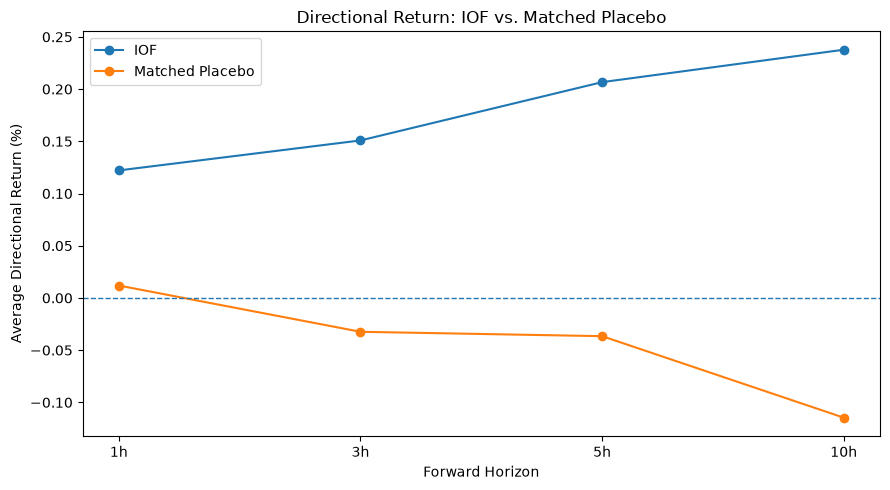

In [41]:
import matplotlib.pyplot as plt

# Convert returns to percentage points
horizon_labels = final_results["Horizon"]

iof_returns = (
    final_results["IOF Mean"] * 100
)

placebo_returns = (
    final_results["Matched Placebo"] * 100
)

plt.figure(figsize=(9, 5))

plt.plot(
    horizon_labels,
    iof_returns,
    marker="o",
    label="IOF"
)

plt.plot(
    horizon_labels,
    placebo_returns,
    marker="o",
    label="Matched Placebo"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Directional Return: IOF vs. Matched Placebo"
)

plt.xlabel("Forward Horizon")
plt.ylabel("Average Directional Return (%)")

plt.legend()

plt.tight_layout()
plt.show()

### Limitations

#### Sample Size

The current dataset contains 26 detected IOF formations, 21 first retests,
and 20 retests with valid historical matched controls.

#### Limited Historical Data

The dataset isn't sufficient to evaluate different market regimes.

#### Exploratory Research

The analysis was not preregistered. The statistical results should
therefore be treated as exploratory rather than definitive evidence of a
persistent market effect.

#### Multiple Horizons

1h, 3h, 5h, and 10h horizons were evaluated, creating a multiple-comparison consideration.

#### No Transaction Costs

Returns are raw price returns and don't account for:

- commissions
- slippage
- bid/ask spread
- execution latency

## 17. Conclusion

In this exploratory sample, first retests of objectively defined IOF zones
exhibited positive average directional returns across the 1-, 3-, 5-, and
10-bar horizons.

The effect remained positive when compared with matched historical placebo
observations selected using time-of-day and recent volatility.

These results are encouraging but are not sufficient to establish a robust
trading edge. The analysis is based on a small sample from approximately
60 days of 1H ES data, and the methodology was developed iteratively.